In [1]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

baseline = joblib.load("../baseline_model/dictionary/baseline_cnn_experiment.pkl")

filters = joblib.load("../Different_filter_number_model/dictionary/more_filters_cnn_experiment.pkl")

deep = joblib.load("../DeeperCNN_model/dictionary/deeper_cnn_experiment.pkl")

adam = joblib.load("../Different_optimizer_algo_model/dictionary/adam_optimizer_cnn_experiment.pkl")

resnet = joblib.load("../RESNET/dictionary/resnet18_experiment.pkl")

In [2]:
all_experiments = [
    baseline,
    filters,
    deep,
    adam,
    resnet
]

comparison = []

for exp in all_experiments:

    comparison.append({
        "Model": exp["name"],
        "Accuracy": exp["accuracy"],
        "Precision": exp["precision"],
        "Recall": exp["recall"],
        "F1": exp["f1"],
        "Optimizer": exp["optimizer"],
        "Batch Size": exp["batch_size"],
        "Epochs": exp["epochs"],
        "Parameters": exp["parameter_count"],
        "Duration": exp["duration"],
    })

df = pd.DataFrame(comparison)

df

,Model,Accuracy,Precision,Recall,F1,Optimizer,Batch Size,Epochs,Parameters,Duration
0,Baseline CNN,0.9909,0.990916,0.9909,0.990897,Adadelta,128,12,1199882,10.174407
1,More Filters CNN,0.9917,0.991710,0.9917,0.991697,Adadelta,128,12,2435210,10.560838
2,Deeper CNN,0.9936,0.993616,0.9936,0.993599,Adadelta,128,12,261962,10.145877
3,Adam Optimizer CNN,0.9910,0.991009,0.9910,0.990998,Adam,128,12,1199882,9.964416
4,ResNet18 Transfer Learning,0.9659,0.966210,0.9659,0.965971,Adam,128,12,11181642,134.058549


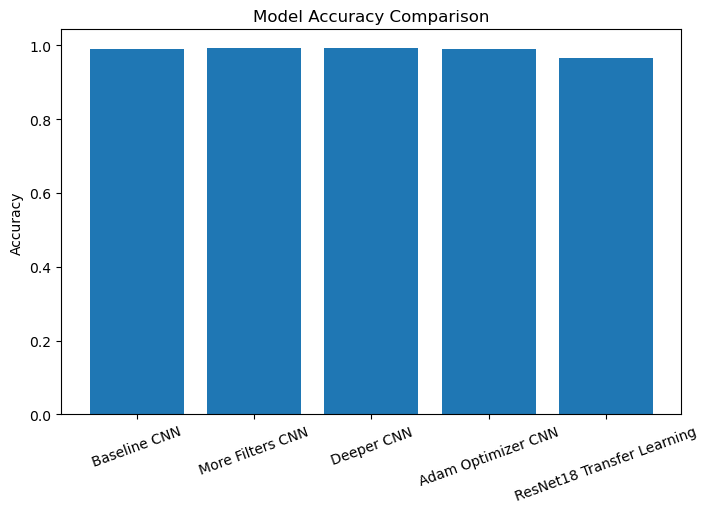

In [3]:
plt.figure(figsize=(8,5))

plt.bar(df["Model"], df["Accuracy"])

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

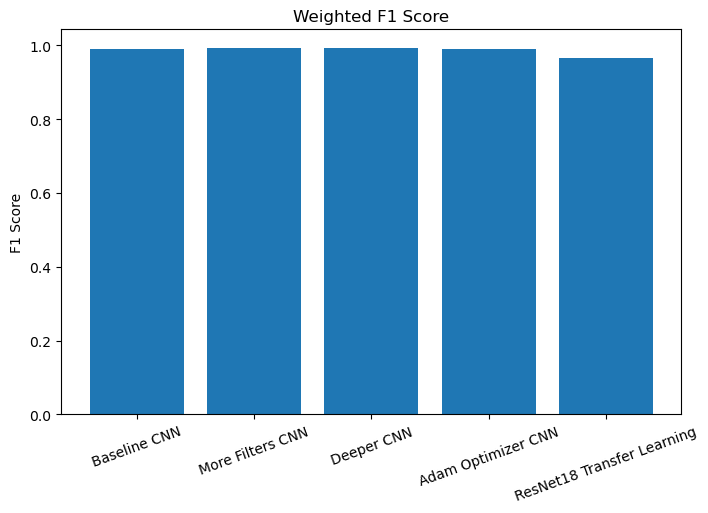

In [4]:
plt.figure(figsize=(8,5))

plt.bar(df["Model"], df["F1"])

plt.title("Weighted F1 Score")

plt.ylabel("F1 Score")

plt.xticks(rotation=20)

plt.show()

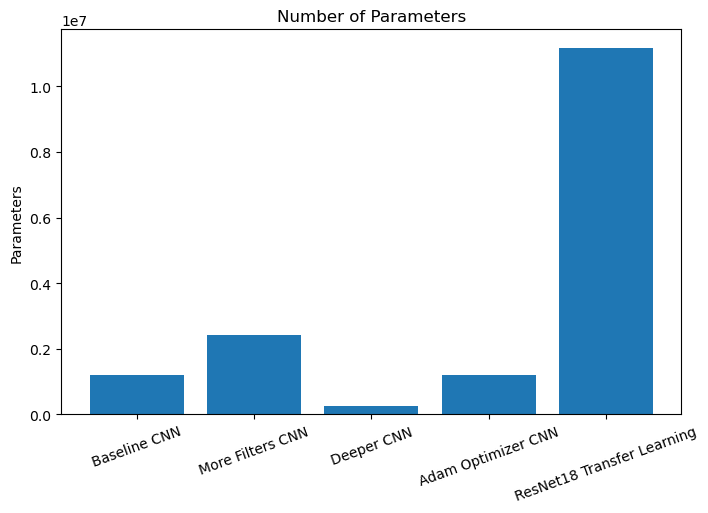

In [5]:
plt.figure(figsize=(8,5))

plt.bar(df["Model"], df["Parameters"])

plt.title("Number of Parameters")

plt.ylabel("Parameters")

plt.xticks(rotation=20)

plt.show()

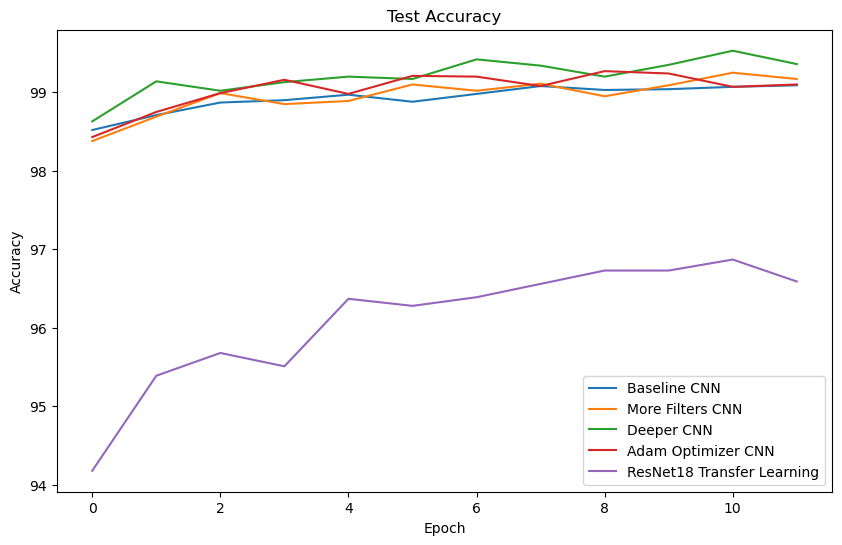

In [6]:
plt.figure(figsize=(10,6))

for exp in all_experiments:

    plt.plot(
        exp["history"]["test_accuracy"],
        label=exp["name"]
    )

plt.title("Test Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

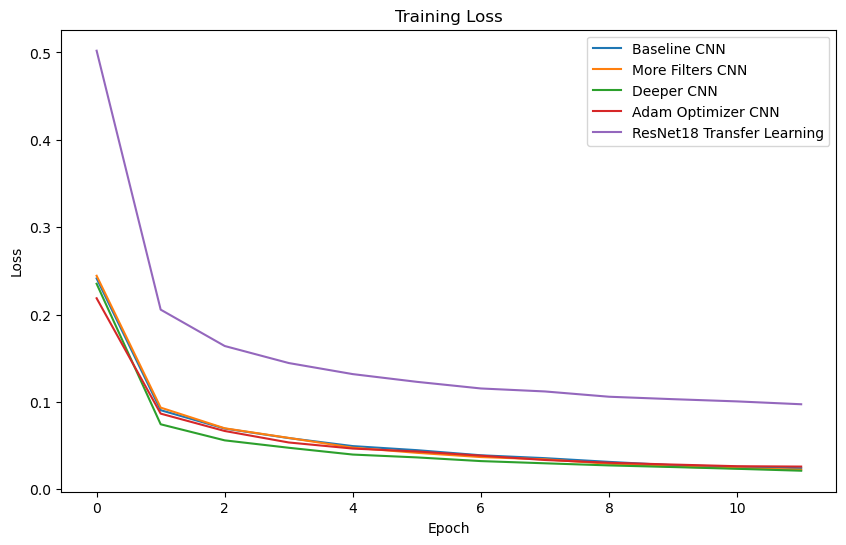

In [7]:
plt.figure(figsize=(10,6))

for exp in all_experiments:

    plt.plot(
        exp["history"]["train_loss"],
        label=exp["name"]
    )

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

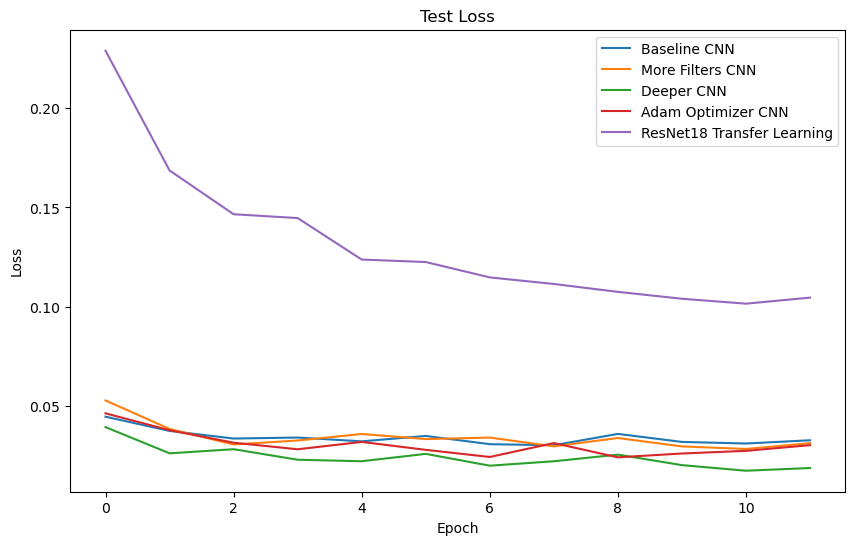

In [8]:
plt.figure(figsize=(10,6))

for exp in all_experiments:

    plt.plot(
        exp["history"]["test_loss"],
        label=exp["name"]
    )

plt.title("Test Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

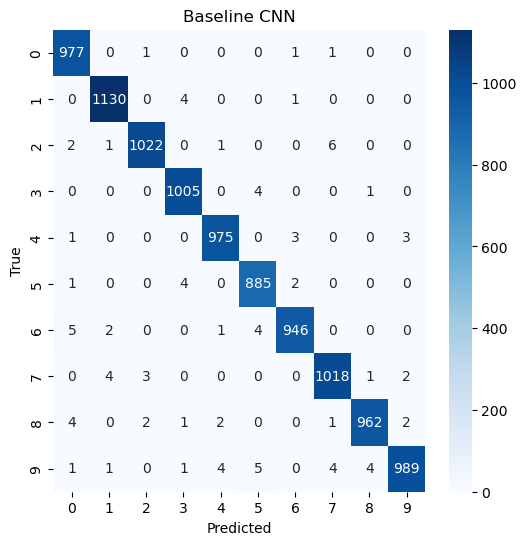

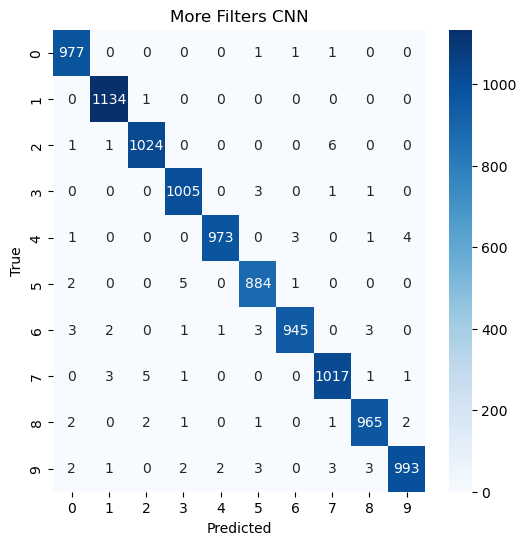

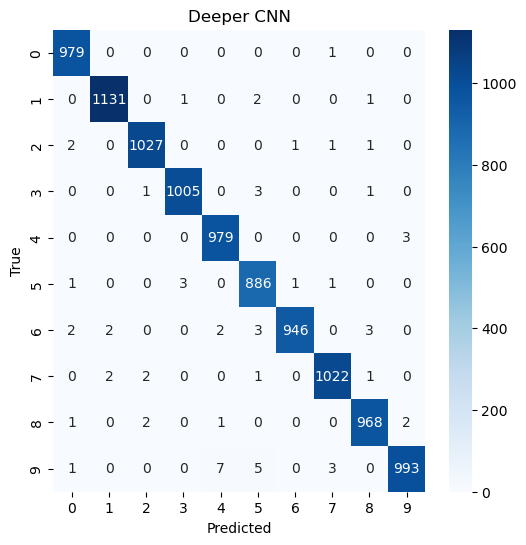

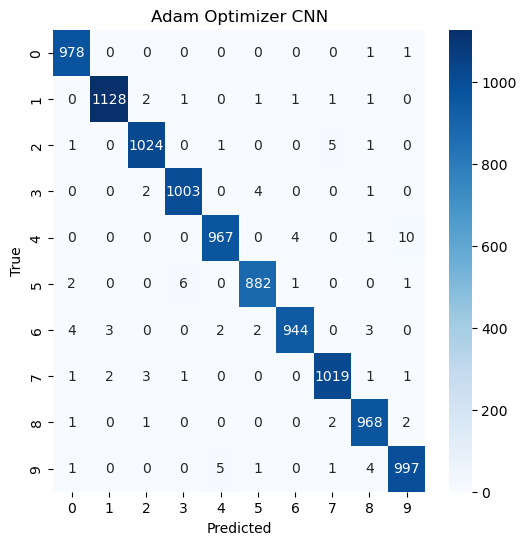

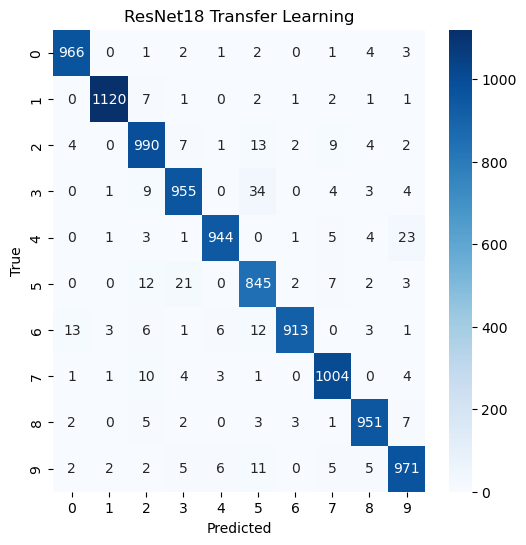

In [11]:
import seaborn as sns

for exp in all_experiments:

    plt.figure(figsize=(6,6))

    sns.heatmap(
        exp["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(exp["name"])

    plt.xlabel("Predicted")

    plt.ylabel("True")

    plt.show()

In [9]:
df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,Optimizer,Batch Size,Epochs,Parameters,Duration
2,Deeper CNN,0.9936,0.993616,0.9936,0.993599,Adadelta,128,12,261962,10.145877
1,More Filters CNN,0.9917,0.991710,0.9917,0.991697,Adadelta,128,12,2435210,10.560838
3,Adam Optimizer CNN,0.9910,0.991009,0.9910,0.990998,Adam,128,12,1199882,9.964416
0,Baseline CNN,0.9909,0.990916,0.9909,0.990897,Adadelta,128,12,1199882,10.174407
4,ResNet18 Transfer Learning,0.9659,0.966210,0.9659,0.965971,Adam,128,12,11181642,134.058549


In [10]:
df.to_csv(
    "Comparison_results/comparison_results.csv",
    index=False
)